In [1]:
# ── Cell 0: Setup (chạy đầu tiên) ──
import os

# Clone repo nếu chưa có
if not os.path.exists('/content/project'):
    !git clone https://github.com/TruongDuyLongPTIT/CTQW_PRO_METABOLITES_PRIORITIZING.git /content/project

# Add src vào Python path
import sys
sys.path.insert(0, '/content/project/src')

# Install dependencies nếu cần
!pip install -q torch scikit-learn networkx tqdm

Cloning into '/content/project'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 46 (delta 17), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 48.72 KiB | 831.00 KiB/s, done.
Resolving deltas: 100% (17/17), done.


In [2]:
from pathlib import Path
from google.colab import drive

if not Path('/content/drive/MyDrive').exists():
    drive.mount('/content/drive')
else:
    print("Drive đã mount sẵn.")

Mounted at /content/drive


In [3]:
!python /content/project/experiments/01_main_results.py

STEP 1 — Build graph
  Graph: 2788 nodes, 22439 edges
  G_pro: 2894 nodes (106 pathway), 31360 edges

STEP 2 — Build eval sets
  hmdb_to_recon: +0 IK, +331 name → 3286 total
  Extracting SMPDB metabolites...
  Disease pathways: 20248
SMPDB files: 100% 48687/48687 [00:34<00:00, 1421.89it/s]
  Loaded 20244 pathways (errors=0)
  Dedup: 20244 → 3240 → 362 → 215
  eval_set1 (HMDB+CTD): 158 diseases
  eval_set2 (MarkerDB): 21 diseases
  eval_set3 (SMPDB):    153 diseases

STEP 3 — Eigendecomposition
  Done.

  Device: cpu

[Table 1] RWR vs CTQW on G_cc...
RWR/HMDB+CTD: 100% 158/158 [11:45<00:00,  4.47s/it]
CTQW/HMDB+CTD: 100% 158/158 [07:52<00:00,  2.99s/it]
  HMDB+CTD: 19.6 min
RWR/MarkerDB: 100% 21/21 [02:28<00:00,  7.09s/it]
CTQW/MarkerDB: 100% 21/21 [01:31<00:00,  4.34s/it]
  MarkerDB: 4.0 min
RWR/SMPDB: 100% 153/153 [09:07<00:00,  3.58s/it]
CTQW/SMPDB: 100% 153/153 [05:39<00:00,  2.22s/it]
  SMPDB: 14.8 min

[Table 2] PROFANCY vs CTQW-PRO on G_pro...
PROFANCY/HMDB+CTD: 100% 158/158 [10:

In [4]:
!python /content/project/experiments/02_ablation_graph.py

Building graphs...
  G_pro: 2894 → clean: 2851 nodes
Building eval sets...
  Disease pathways: 20248
SMPDB files: 100% 48687/48687 [00:41<00:00, 1180.37it/s]
  Loaded 20244 pathways (errors=0)
  Dedup: 20244 → 3240 → 362 → 215
Eigendecomposition...

Running ablation...
PROF_o/HMDB+CTD: 100% 158/158 [11:32<00:00,  4.38s/it]
CTQW_o/HMDB+CTD: 100% 158/158 [08:03<00:00,  3.06s/it]
PROF_c/HMDB+CTD: 100% 158/158 [14:56<00:00,  5.68s/it]
CTQW_c/HMDB+CTD: 100% 158/158 [09:16<00:00,  3.52s/it]
  HMDB+CTD: 43.8 min
PROF_o/MarkerDB: 100% 21/21 [01:52<00:00,  5.37s/it]
CTQW_o/MarkerDB: 100% 21/21 [01:27<00:00,  4.17s/it]
PROF_c/MarkerDB: 100% 21/21 [03:02<00:00,  8.70s/it]
CTQW_c/MarkerDB: 100% 21/21 [01:40<00:00,  4.78s/it]
  MarkerDB: 8.1 min
PROF_o/SMPDB: 100% 153/153 [07:39<00:00,  3.01s/it]
CTQW_o/SMPDB: 100% 153/153 [06:00<00:00,  2.35s/it]
PROF_c/SMPDB: 100% 153/153 [11:46<00:00,  4.62s/it]
CTQW_c/SMPDB: 100% 153/153 [07:10<00:00,  2.81s/it]
  SMPDB: 32.6 min

ABLATION: Original vs Clean G_

In [5]:
!python /content/project/experiments/03_negative_results.py

Setup...
  Disease pathways: 20248
SMPDB files: 100% 48687/48687 [00:34<00:00, 1428.77it/s]
  Loaded 20244 pathways (errors=0)
  Dedup: 20244 → 3240 → 362 → 215
  SMPDB: 153 diseases
  Device: cpu

EXP 1: Chiral Quantum Walk
  Directed edges: 11099/31360 (35.4%)
Chiral φ=0: 100% 153/153 [01:06<00:00,  2.30it/s]
Chiral φ=π/8: 100% 153/153 [01:09<00:00,  2.19it/s]
Chiral φ=π/4: 100% 153/153 [01:01<00:00,  2.49it/s]
Chiral φ=π/3: 100% 153/153 [01:04<00:00,  2.38it/s]
Chiral φ=π/2: 100% 153/153 [01:06<00:00,  2.31it/s]

  φ           AUC      MRR    R@20
  ----------------------------
  0        0.9568   0.2172  0.5429
  π/8      0.9462   0.1858  0.5095
  π/4      0.9444   0.1624  0.4762
  π/3      0.9337   0.1367  0.4280
  π/2      0.9289   0.1740  0.4807
  Conclusion: Chiral walk does NOT improve — graph not sufficiently directed.

EXP 2: Geometric t schedule
Geometric-t: 100% 153/153 [07:36<00:00,  2.98s/it]
  Geometric-t: 7.6 min

  Method                      MRR     R@20
  ----------

In [ ]:
!apt-get install -y texlive-xetex texlive-fonts-recommended \
    texlive-plain-generic cm-super dvipng 2>/dev/null

Fig 1: bar chart


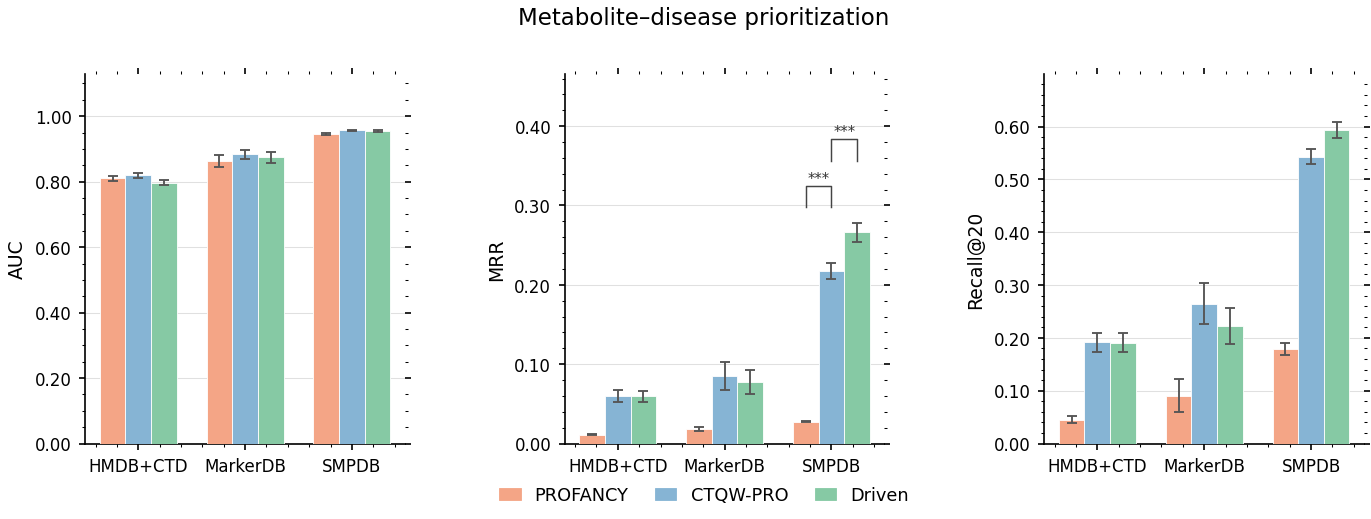

  saved fig1_bar

Fig 2: scatter


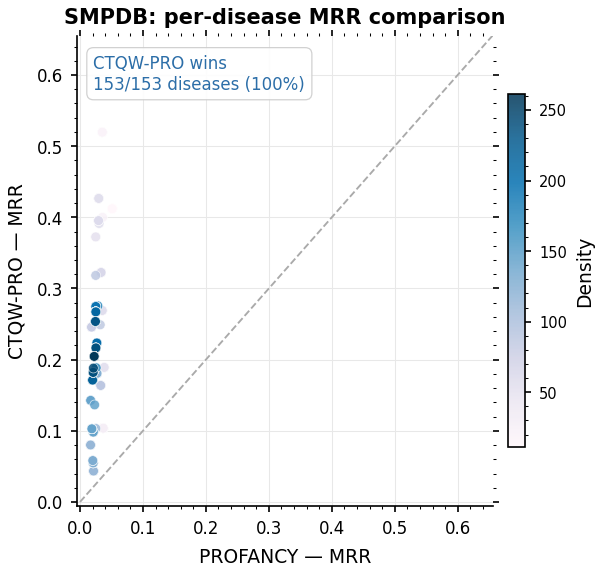

  saved fig2_scatter

Fig 3: violin


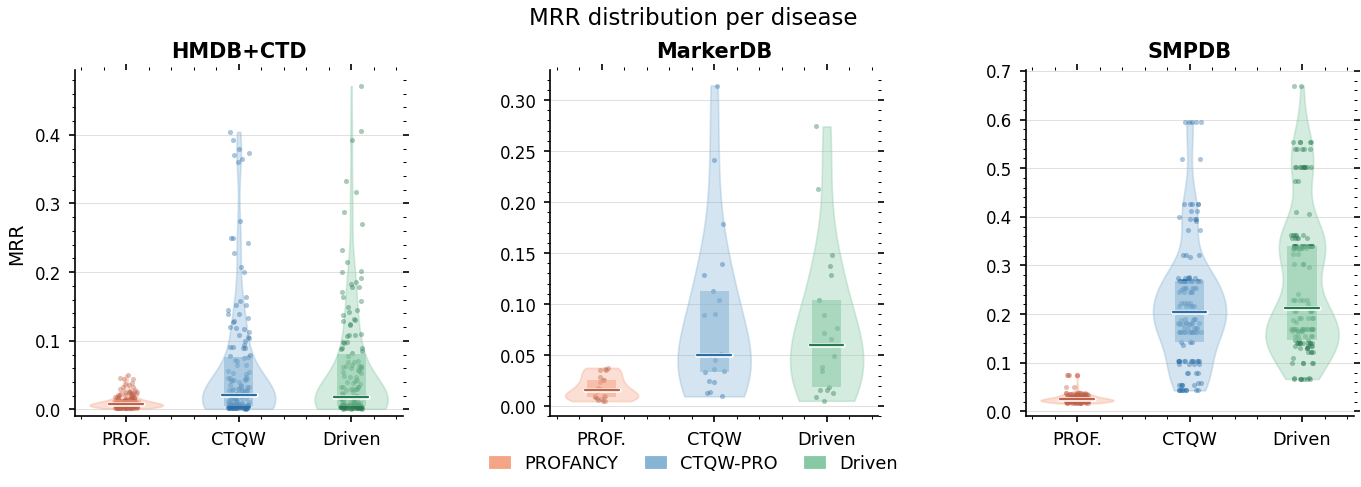

  saved fig3_violin

Fig 4: recall@k


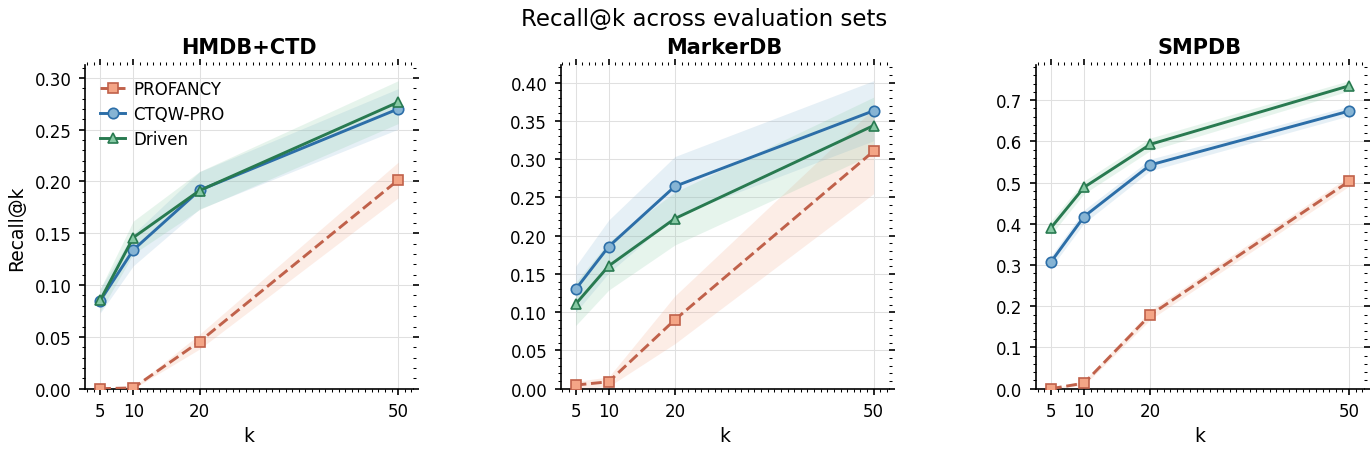

  saved fig4_recall

✓ All figures saved.


In [22]:
# ════════════════════════════════════════════════════════════════
# FIGURES — Clean pastel, no LaTeX, no overlap
# ════════════════════════════════════════════════════════════════
%matplotlib inline
import sys
sys.path.insert(0, '/content/project/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import warnings; warnings.filterwarnings('ignore')
from scipy.stats import gaussian_kde
from config import RESULTS_DIR

# ── Style: clean, no LaTeX ────────────────────────────────────
plt.rcParams.update({
    'text.usetex':          False,
    'font.family':          'sans-serif',
    'font.sans-serif':      ['DejaVu Sans','Arial','Helvetica'],
    'font.size':            9,
    'axes.labelsize':       9,
    'axes.titlesize':       10,
    'axes.titleweight':     'bold',
    'axes.linewidth':       0.8,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'xtick.labelsize':      8,
    'ytick.labelsize':      8,
    'xtick.major.size':     3,
    'ytick.major.size':     3,
    'xtick.major.width':    0.8,
    'ytick.major.width':    0.8,
    'xtick.direction':      'out',
    'ytick.direction':      'out',
    'legend.fontsize':      8,
    'legend.frameon':       False,
    'lines.linewidth':      1.5,
    'figure.dpi':           150,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
})

# ── Pastel palette ────────────────────────────────────────────
PROF_C   = '#F4A586'   # pastel coral
CTQW_C   = '#86B4D4'   # pastel blue
DRIVEN_C = '#86C9A4'   # pastel green

PROF_D   = '#C0614A'   # dark coral (for text/markers)
CTQW_D   = '#2C6EA8'
DRIVEN_D = '#287A50'

COLS  = [PROF_C,   CTQW_C,   DRIVEN_C]
DCOLS = [PROF_D,   CTQW_D,   DRIVEN_D]
MKEYS = ['PROFANCY', 't=0.1', 'driven_s2_a0.5']
MLBLS = ['PROFANCY', 'CTQW-PRO', 'Driven']
SETS  = ['HMDB+CTD', 'MarkerDB', 'SMPDB']
SLBLS = ['HMDB+CTD', 'MarkerDB', 'SMPDB']

FIGS_DIR = RESULTS_DIR / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    for ext in ('pdf','png'):
        fig.savefig(FIGS_DIR/f'{name}.{ext}', dpi=300)
    print(f'  saved {name}')

# ── Data ──────────────────────────────────────────────────────
df_all = pd.read_csv(RESULTS_DIR / 'main_results.csv')
df_wx  = pd.read_csv(RESULTS_DIR / 'wilcoxon_results.csv') \
         if (RESULTS_DIR/'wilcoxon_results.csv').exists() else None

TABLE_MAP = {'PROFANCY':'table2','t=0.1':'table2',
             'driven_s2_a0.5':'table3'}

def gdf(mk, src):
    tbl = TABLE_MAP.get(mk,'table2')
    return df_all[(df_all['table']==tbl)&(df_all['method']==mk)
                  &(df_all['source']==src)]

def mu(mk,src,k):
    d=gdf(mk,src); return float(d[k].mean()) if not d.empty else 0.0

def se(mk,src,k):
    d=gdf(mk,src); return float(d[k].sem())  if len(d)>1 else 0.0

def getp(src,met,idx=0):
    if df_wx is None: return 1.0
    r=df_wx[(df_wx['source']==src)&(df_wx['metric']==met)]
    return float(r['p_bonf'].values[idx]) if len(r)>idx else 1.0

def stars(p):
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''

def bracket(ax, x1, x2, y, h, txt, fs=7):
    ax.plot([x1,x1,x2,x2],[y,y+h,y+h,y], lw=0.7, c='#444')
    ax.text((x1+x2)/2, y+h, txt, ha='center', va='bottom',
            fontsize=fs, color='#333')

# ════════════════════════════════════════════════════════════════
# FIG 1 — Grouped bar: AUC / MRR / Recall@20
# ════════════════════════════════════════════════════════════════
print('Fig 1: bar chart')
METS1 = [('auc','AUC'), ('mrr','MRR'), ('r@20','Recall@20')]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2),
                          gridspec_kw={'wspace':0.50})

for ax, (met, mlbl) in zip(axes, METS1):
    x = np.arange(len(SETS))
    w = 0.24
    off = np.array([-w, 0, w])

    for j,(mk,ml,c,dc) in enumerate(zip(MKEYS,MLBLS,COLS,DCOLS)):
        v = np.array([mu(mk,s,met) for s in SETS])
        e = np.array([se(mk,s,met) for s in SETS])
        ax.bar(x+off[j], v, w, color=c, label=ml,
               edgecolor='white', linewidth=0.4, zorder=3)
        ax.errorbar(x+off[j], v, e, fmt='none',
                    ecolor='#555', elinewidth=0.9,
                    capsize=2.5, capthick=0.9, zorder=4)

    # Significance bracket trên SMPDB (MRR thôi cho gọn)
    if met == 'mrr':
        vals = [mu(mk,'SMPDB',met) for mk in MKEYS]
        top  = max(vals)
        ylim = top * 1.75
        ax.set_ylim(0, ylim)
        p1 = getp('SMPDB','mrr',0)
        p2 = getp('SMPDB','mrr',1)
        s1 = stars(p1); s2 = stars(p2)
        if s1:
            bracket(ax, x[2]+off[0], x[2]+off[1],
                    top*1.12, top*0.10, s1)
        if s2:
            bracket(ax, x[2]+off[1], x[2]+off[2],
                    top*1.34, top*0.10, s2)
    else:
        vals_all = [mu(mk,s,met) for mk in MKEYS for s in SETS]
        ax.set_ylim(0, max(vals_all)*1.18)

    ax.set_ylabel(mlbl, labelpad=4)
    ax.set_xticks(x)
    ax.set_xticklabels(SLBLS, fontsize=8)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

# Legend dưới figure
handles = [mpatches.Patch(color=c, label=l)
           for c,l in zip(COLS, MLBLS)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5,-0.05), fontsize=8.5,
           frameon=False, handlelength=1.2, columnspacing=1.5)
fig.suptitle('Metabolite–disease prioritization', fontsize=11, y=1.02)
plt.show(); savefig(fig,'fig1_bar')

# ════════════════════════════════════════════════════════════════
# FIG 2 — Scatter PROFANCY vs CTQW-PRO (SMPDB, MRR)
# ════════════════════════════════════════════════════════════════
print('\nFig 2: scatter')
dfp = gdf('PROFANCY','SMPDB').set_index('disease')
dfc = gdf('t=0.1',  'SMPDB').set_index('disease')
shared = sorted(set(dfp.index)&set(dfc.index))
mp = dfp.loc[shared,'mrr'].values
mc = dfc.loc[shared,'mrr'].values

fig, ax = plt.subplots(figsize=(4.2, 4.0))

# KDE coloring
try:
    kde = gaussian_kde(np.vstack([mp, mc]))
    z   = kde(np.vstack([mp, mc]))
    idx = z.argsort()
    sc  = ax.scatter(mp[idx], mc[idx], c=z[idx],
                     cmap='PuBu', s=22, alpha=0.85,
                     linewidths=0.3, edgecolors='white', zorder=3)
    cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03,
                      label='Density')
    cb.ax.tick_params(labelsize=7)
except Exception:
    ax.scatter(mp, mc, color=CTQW_C, s=22, alpha=0.7, zorder=3)

lim = max(mp.max(), mc.max())*1.1
ax.plot([0,lim],[0,lim],'--', color='#aaa', lw=0.9, zorder=2)
ax.set_xlim(-0.005,lim); ax.set_ylim(-0.005,lim)
ax.set_xlabel('PROFANCY — MRR', labelpad=5)
ax.set_ylabel('CTQW-PRO — MRR', labelpad=5)
ax.set_title('SMPDB: per-disease MRR comparison')
n_win = (mc>mp).sum()
ax.text(0.04, 0.96,
        f'CTQW-PRO wins\n{n_win}/{len(shared)} diseases ({100*n_win/len(shared):.0f}%)',
        ha='left', va='top', transform=ax.transAxes,
        fontsize=8, color=CTQW_D,
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec='#ccc', lw=0.6, alpha=0.9))
ax.grid(color='#e8e8e8', linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show(); savefig(fig,'fig2_scatter')

# ════════════════════════════════════════════════════════════════
# FIG 3 — Violin + strip per eval set
# ════════════════════════════════════════════════════════════════
print('\nFig 3: violin')
rng = np.random.default_rng(42)
XLBLS = ['PROF.', 'CTQW', 'Driven']   # short labels → no overlap

fig, axes = plt.subplots(1, 3, figsize=(11, 3.0),
                          gridspec_kw={'wspace':0.45})

for ax, src, stitle in zip(axes, SETS, SLBLS):
    data = [gdf(mk,src)['mrr'].values for mk in MKEYS]
    data = [(d,l,c,dc) for d,l,c,dc in
            zip(data,MLBLS,COLS,DCOLS) if len(d)>1]
    if not data: continue

    vp = ax.violinplot([d for d,_,_,_ in data],
                       positions=range(len(data)),
                       showmedians=False, showextrema=False,
                       widths=0.65)
    for body,(_,_,c,_) in zip(vp['bodies'],data):
        body.set_facecolor(c); body.set_alpha(0.35)
        body.set_edgecolor(c); body.set_linewidth(0.8)

    for i,(d,_,c,dc) in enumerate(data):
        q25,med,q75 = np.percentile(d,[25,50,75])
        # IQR box
        ax.fill_between([i-0.13,i+0.13],[q25,q25],[q75,q75],
                        color=c, alpha=0.55, linewidth=0, zorder=3)
        # Median
        ax.plot([i-0.15,i+0.15],[med,med],
                lw=2.2, c='white', solid_capstyle='round', zorder=4)
        ax.plot([i-0.15,i+0.15],[med,med],
                lw=1.1, c=dc, solid_capstyle='round', zorder=5)
        # Jitter points
        jitter = rng.uniform(-0.10,0.10,len(d))
        ax.scatter(i+jitter, d, s=6, color=dc,
                   alpha=0.40, linewidths=0, zorder=2)

    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(XLBLS[:len(data)], fontsize=8.5)
    ax.set_ylabel('MRR' if src=='HMDB+CTD' else '', labelpad=4)
    ax.set_title(stitle)
    ax.set_ylim(bottom=-0.01)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

# Legend
handles = [mpatches.Patch(color=c, label=l)
           for c,l in zip(COLS, MLBLS)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5,-0.05), fontsize=8.5,
           frameon=False, handlelength=1.2, columnspacing=1.5)
fig.suptitle('MRR distribution per disease', fontsize=11, y=1.02)
plt.show(); savefig(fig,'fig3_violin')

# ════════════════════════════════════════════════════════════════
# FIG 4 — Recall@k curves + SE shading
# ════════════════════════════════════════════════════════════════
print('\nFig 4: recall@k')
K_VALS = [5, 10, 20, 50]
MSTYLE = [
    ('PROFANCY', 'PROFANCY',    PROF_C,   PROF_D,   '--', 's'),
    ('t=0.1',    'CTQW-PRO',   CTQW_C,   CTQW_D,   '-',  'o'),
    ('driven_s2_a0.5','Driven', DRIVEN_C, DRIVEN_D, '-',  '^'),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 2.8),
                          gridspec_kw={'wspace':0.45})

for ax, src, stitle in zip(axes, SETS, SLBLS):
    for mk,ml,c,dc,ls,mk_ in MSTYLE:
        d = gdf(mk,src)
        if d.empty: continue
        means = [float(d[f'r@{k}'].mean()) for k in K_VALS]
        sems  = [float(d[f'r@{k}'].sem())  for k in K_VALS]
        means, sems = np.array(means), np.array(sems)
        ax.plot(K_VALS, means, ls, color=dc, markersize=5,
                marker=mk_, label=ml, linewidth=1.4,
                markerfacecolor=c, markeredgecolor=dc,
                markeredgewidth=0.8, zorder=4)
        ax.fill_between(K_VALS, means-sems, means+sems,
                        color=c, alpha=0.20, linewidth=0, zorder=2)

    ax.set_xlabel('k', labelpad=3)
    ax.set_ylabel('Recall@k' if src=='HMDB+CTD' else '', labelpad=4)
    ax.set_title(stitle)
    ax.set_xticks(K_VALS)
    ax.set_xticklabels(K_VALS, fontsize=8)
    ax.set_ylim(bottom=0)
    ax.grid(color='#e0e0e0', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

axes[0].legend(loc='upper left', fontsize=8,
               handlelength=1.5, labelspacing=0.4,
               borderpad=0.4, handletextpad=0.5)
fig.suptitle('Recall@k across evaluation sets', fontsize=11, y=1.02)
plt.show(); savefig(fig,'fig4_recall')

print('\n✓ All figures saved.')